# Bottleneck & Latent Space Optimization Analysis

In this notebook, we'll focus specifically on the bottleneck architecture optimization:

```
latent-space → Reshape(Nlat-space, 1, 1, 1) → Upsampling3D(Nlat-space, Nx, Ny, Nz) 
→ Conv3D(Nlat-space, Nlat-space, (Nx, Ny, Nz), groups = Nlat-space) 
→ Conv3D(Nlat-space, Nchan, 1) → Activation
```

This approach associates each latent space variable with a "basis image" and combines them
by weighing them by the latent space intensity, significantly reducing parameter count.

## Setup & Imports

In [31]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
from collections import OrderedDict
import matplotlib.pyplot as plt
from pathlib import Path
import os

# Runtime reload
import importlib
import models.autoencoder.selected_model
importlib.reload(models.autoencoder.selected_model)


from data.data_ingestion import collect_files, generate_dataframe
from data.dataloader import OnDemandDataset
from models.autoencoder.selected_model import (
    BaseEncoder,
    BaseDecoder,
    BottleneckEncoder,
    BottleneckBasisDecoder,
    BottleneckHybridDecoder,
    BottleneckDeconvDecoder,
    BottleneckAE,
    SpatialAE,
)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def save_model(m, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    torch.save(m.state_dict(), path)


Device: cpu


## Quick Smoke Test

In [17]:
# Quick function to instantiate each pipeline, run a forward with dummy input and print stats
def smoke_test_pipeline(batch=1, input_shape=(1,64,128,128), latent_dim=128, bottleneck_shape=(1,1,1)):
    B, C, D, H, W = batch, input_shape[0], input_shape[1], input_shape[2], input_shape[3]
    dummy = torch.randn(B, C, D, H, W).to(device)
    print("Dummy input:", dummy.shape)

    # 1) Vanilla AE (spatial latent)
    enc_v = BaseEncoder(initial_filters=4).to(device)
    dec_v = BaseDecoder(latent_dim=128).to(device)
    ae_v = SpatialAE(enc_v, dec_v).to(device)
    with torch.no_grad():
        out_v = ae_v(dummy)
    print("Vanilla AE out:", out_v.shape, "params:", count_parameters(ae_v))

    # 2) Bottleneck Basis
    enc_b = BottleneckEncoder(initial_filters=4, latent_dim=latent_dim, bottleneck_shape=bottleneck_shape).to(device)
    dec_basis = BottleneckBasisDecoder(latent_dim=latent_dim, initial_shape=(4,8,8)).to(device)
    ae_basis = BottleneckAE(enc_b, dec_basis).to(device)
    with torch.no_grad():
        out_basis = ae_basis(dummy)
    print("Bottleneck Basis out:", out_basis.shape, "params:", count_parameters(ae_basis))

    # 3) Bottleneck Deconv
    enc_b2 = BottleneckEncoder(initial_filters=4, latent_dim=latent_dim, bottleneck_shape=bottleneck_shape).to(device)
    dec_deconv = BottleneckDeconvDecoder(latent_dim=latent_dim, initial_shape=(4,8,8)).to(device)
    ae_deconv = BottleneckAE(enc_b2, dec_deconv).to(device)
    with torch.no_grad():
        out_deconv = ae_deconv(dummy)
    print("Bottleneck Deconv out:", out_deconv.shape, "params:", count_parameters(ae_deconv))

    # 4) Bottleneck Hybrid
    enc_b3 = BottleneckEncoder(initial_filters=4, latent_dim=latent_dim, bottleneck_shape=bottleneck_shape).to(device)
    dec_hy = BottleneckHybridDecoder(latent_dim=latent_dim, initial_shape=(4,8,8)).to(device)
    ae_hy = BottleneckAE(enc_b3, dec_hy).to(device)
    with torch.no_grad():
        out_hy = ae_hy(dummy)
    print("Bottleneck Hybrid out:", out_hy.shape, "params:", count_parameters(ae_hy))

In [18]:
# Run a smoke test
smoke_test_pipeline(batch=1, input_shape=(1,64,128,128), latent_dim=128, bottleneck_shape=(1,1,1))

Dummy input: torch.Size([1, 1, 64, 128, 128])
Vanilla AE out: torch.Size([1, 1, 64, 128, 128]) params: 955673


d:\UNIMIB\Thesis\refactoried_project\venv\Lib\site-packages\torch\nn\modules\conv.py:712: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\Convolution.cpp:1028.)
  return F.conv3d(


Bottleneck Basis out: torch.Size([1, 1, 64, 128, 128]) params: 778065
Bottleneck Deconv out: torch.Size([1, 1, 64, 128, 128]) params: 2834129
Bottleneck Hybrid out: torch.Size([1, 1, 64, 128, 128]) params: 781585


In [19]:
def extended_test_suite(
    batch=1,
    input_shape=(1,64,128,128),
    latent_dim_list=[32,64,128],
    bottleneck_shapes=[(1,1,1),(2,4,4)],
    group_settings=['full','partial','none']
):
    results = []
    for latent_dim in latent_dim_list:
        for bshape in bottleneck_shapes:
            for gset in group_settings:
                print(f"\n🧪 latent_dim={latent_dim}  bottleneck_shape={bshape}  groups={gset}")

                # base encoder + basis decoder with group variants
                enc = BottleneckEncoder(initial_filters=4, latent_dim=latent_dim, bottleneck_shape=bshape).to(device)
                if gset == 'full':
                    groups = latent_dim
                elif gset == 'partial':
                    groups = max(1, latent_dim//4)
                else:
                    groups = 1

                # modify grouped_conv groups dynamically
                dec_basis = BottleneckBasisDecoder(latent_dim=latent_dim, initial_shape=(4,8,8)).to(device)
                dec_basis.grouped_conv = nn.Conv3d(latent_dim, latent_dim, kernel_size=(4,8,8), groups=groups).to(device)

                ae_basis = BottleneckAE(enc, dec_basis).to(device)
                dummy = torch.randn(batch, *input_shape).to(device)
                with torch.no_grad():
                    out = ae_basis(dummy)
                results.append({
                    'variant': 'basis',
                    'latent_dim': latent_dim,
                    'bottleneck_shape': bshape,
                    'groups': groups,
                    'params': count_parameters(ae_basis),
                    'output_shape': tuple(out.shape)
                })

                # deconv variant (no groups)
                enc2 = BottleneckEncoder(initial_filters=4, latent_dim=latent_dim, bottleneck_shape=bshape).to(device)
                dec_deconv = BottleneckDeconvDecoder(latent_dim=latent_dim, initial_shape=(4,8,8)).to(device)
                ae_deconv = BottleneckAE(enc2, dec_deconv).to(device)
                with torch.no_grad():
                    out2 = ae_deconv(dummy)
                results.append({
                    'variant': 'deconv',
                    'latent_dim': latent_dim,
                    'bottleneck_shape': bshape,
                    'groups': 1,
                    'params': count_parameters(ae_deconv),
                    'output_shape': tuple(out2.shape)
                })

                # hybrid variant
                enc3 = BottleneckEncoder(initial_filters=4, latent_dim=latent_dim, bottleneck_shape=bshape).to(device)
                dec_hy = BottleneckHybridDecoder(latent_dim=latent_dim, initial_shape=(4,8,8)).to(device)
                ae_hy = BottleneckAE(enc3, dec_hy).to(device)
                with torch.no_grad():
                    out3 = ae_hy(dummy)
                results.append({
                    'variant': 'hybrid',
                    'latent_dim': latent_dim,
                    'bottleneck_shape': bshape,
                    'groups': 'N/A',
                    'params': count_parameters(ae_hy),
                    'output_shape': tuple(out3.shape)
                })
    df = pd.DataFrame(results)
    display(df)
    return df



In [20]:
# Run the extended test
df_results = extended_test_suite(batch=1, input_shape=(1,32,64,64), latent_dim_list=[32,64], bottleneck_shapes=[(1,1,1),(2,4,4)], group_settings=['full','partial','none'])



🧪 latent_dim=32  bottleneck_shape=(1, 1, 1)  groups=full

🧪 latent_dim=32  bottleneck_shape=(1, 1, 1)  groups=partial

🧪 latent_dim=32  bottleneck_shape=(1, 1, 1)  groups=none

🧪 latent_dim=32  bottleneck_shape=(2, 4, 4)  groups=full

🧪 latent_dim=32  bottleneck_shape=(2, 4, 4)  groups=partial

🧪 latent_dim=32  bottleneck_shape=(2, 4, 4)  groups=none

🧪 latent_dim=64  bottleneck_shape=(1, 1, 1)  groups=full

🧪 latent_dim=64  bottleneck_shape=(1, 1, 1)  groups=partial

🧪 latent_dim=64  bottleneck_shape=(1, 1, 1)  groups=none

🧪 latent_dim=64  bottleneck_shape=(2, 4, 4)  groups=full

🧪 latent_dim=64  bottleneck_shape=(2, 4, 4)  groups=partial

🧪 latent_dim=64  bottleneck_shape=(2, 4, 4)  groups=none


,variant,latent_dim,bottleneck_shape,groups,params,output_shape
0,basis,32,"(1, 1, 1)",32,751377,"(1, 1, 64, 128, 128)"
1,deconv,32,"(1, 1, 1)",1,1265393,"(1, 1, 64, 128, 128)"
2,hybrid,32,"(1, 1, 1)",N/A,776881,"(1, 1, 64, 128, 128)"
3,basis,32,"(1, 1, 1)",8,775953,"(1, 1, 64, 128, 128)"
4,deconv,32,"(1, 1, 1)",1,1265393,"(1, 1, 64, 128, 128)"
5,hybrid,32,"(1, 1, 1)",N/A,776881,"(1, 1, 64, 128, 128)"
6,basis,32,"(1, 1, 1)",1,1005329,"(1, 1, 64, 128, 128)"
7,deconv,32,"(1, 1, 1)",1,1265393,"(1, 1, 64, 128, 128)"
8,hybrid,32,"(1, 1, 1)",N/A,776881,"(1, 1, 64, 128, 128)"
9,basis,32,"(2, 4, 4)",32,751377,"(1, 1, 64, 128, 128)"


## Data setup

In [22]:
root_dir = Path("d:/UNIMIB/Thesis/refactoried_project")
images_dir = root_dir / "data" / "Images"
mask_path = root_dir / "data" / "masks" / "rmask_ICV.nii"

In [24]:
included, excluded = collect_files(str(images_dir))
df = generate_dataframe(included)
assert not df.empty, "No DICOM files found. Check `images_dir`."
df.head()

,file_path,label
0,d:\UNIMIB\Thesis\refactoried_project\data\Imag...,Control
1,d:\UNIMIB\Thesis\refactoried_project\data\Imag...,Control
2,d:\UNIMIB\Thesis\refactoried_project\data\Imag...,Control
3,d:\UNIMIB\Thesis\refactoried_project\data\Imag...,Control
4,d:\UNIMIB\Thesis\refactoried_project\data\Imag...,Control


In [25]:
from torch.utils.data import DataLoader

# keep evaluation lightweight: on-demand loading, batch=1
eval_dataset = OnDemandDataset(df.sample(n=12, random_state=7).reset_index(drop=True),
                               mask_path=str(mask_path))
eval_loader = DataLoader(eval_dataset, batch_size=1, shuffle=False, num_workers=0)
len(eval_dataset)

✅ Brain mask loaded successfully
✅ All 12 file paths are valid


12

## Model Setup

In [27]:
target_shape = (64, 128, 128)

def make_models(latent_dim=128, bottleneck_shape=(1, 1, 1), basis_groups="full"):
    vanilla = SpatialAE(
        BaseEncoder(initial_filters=4).to(device),
        BaseDecoder(latent_dim=128).to(device),
    )

    encoder = lambda: BottleneckEncoder(
        initial_filters=4,
        latent_dim=latent_dim,
        bottleneck_shape=bottleneck_shape,
    ).to(device)

    basis = BottleneckAE(
        encoder(),
        BottleneckBasisDecoder(
            latent_dim=latent_dim,
            initial_shape=bottleneck_shape,
            target_shape=target_shape,
            groups=basis_groups,
        ).to(device),
    )
    deconv = BottleneckAE(
        encoder(),
        BottleneckDeconvDecoder(
            latent_dim=latent_dim,
            initial_shape=bottleneck_shape,
            target_shape=target_shape,
        ).to(device),
    )
    hybrid = BottleneckAE(
        encoder(),
        BottleneckHybridDecoder(
            latent_dim=latent_dim,
            initial_shape=bottleneck_shape,
            target_shape=target_shape,
        ).to(device),
    )
    return {
        "vanilla": vanilla,
        "basis": basis,
        "deconv": deconv,
        "hybrid": hybrid,
    }

def reconstruction_metrics(x, x_hat):
    mse = F.mse_loss(x_hat, x).item()
    mae = F.l1_loss(x_hat, x).item()
    return {"mse": mse, "mae": mae}

In [28]:
def evaluate_variants(latent_dim=128, bottleneck_shape=(1,1,1), basis_groups="full"):
    models = make_models(latent_dim, bottleneck_shape, basis_groups)
    for m in models.values():
        m.eval()

    records, recon_store = [], []

    with torch.no_grad():
        for idx, batch in enumerate(eval_loader):
            vol = batch["volume"].to(device)
            meta = {"path": batch["path"][0], "label": batch["label"][0]}

            for name, model in models.items():
                recon = model(vol)
                metrics = reconstruction_metrics(vol, recon)
                param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
                records.append({
                    "sample": idx,
                    "variant": name,
                    "params": param_count,
                    **metrics,
                    **meta,
                })
                if idx < 6:   # store a few for visualization
                    recon_store.append({
                        "sample": idx,
                        "variant": name,
                        "input": vol.cpu(),
                        "recon": recon.cpu(),
                    })
    return pd.DataFrame(records), recon_store


In [29]:
results_df, recon_bank = evaluate_variants(
    latent_dim=128,
    bottleneck_shape=(1,1,1),
    basis_groups="partial"  # or 'full'/'none'/int
)
results_df.sort_values(["sample","variant"]).head()

,sample,variant,params,mse,mae,path,label
1,0,basis,745809,0.647270,0.680138,d:\UNIMIB\Thesis\refactoried_project\data\Imag...,PD
2,0,deconv,745169,0.197516,0.269143,d:\UNIMIB\Thesis\refactoried_project\data\Imag...,PD
3,0,hybrid,781585,0.301210,0.341420,d:\UNIMIB\Thesis\refactoried_project\data\Imag...,PD
0,0,vanilla,955673,0.490369,0.552904,d:\UNIMIB\Thesis\refactoried_project\data\Imag...,PD
5,1,basis,745809,0.686784,0.697790,d:\UNIMIB\Thesis\refactoried_project\data\Imag...,PD


In [30]:
summary = (
    results_df.groupby("variant")[["mse","mae","params"]]
    .agg(["mean","std"])
    .round(6)
)
summary

mse                 mae              params     
             mean       std      mean       std      mean  std
variant                                                       
basis    0.680062  0.027745  0.692859  0.008972  745809.0  0.0
deconv   0.215873  0.017963  0.281864  0.008972  745169.0  0.0
hybrid   0.325380  0.021858  0.354141  0.008972  781585.0  0.0
vanilla  0.519920  0.025523  0.565626  0.008972  955673.0  0.0

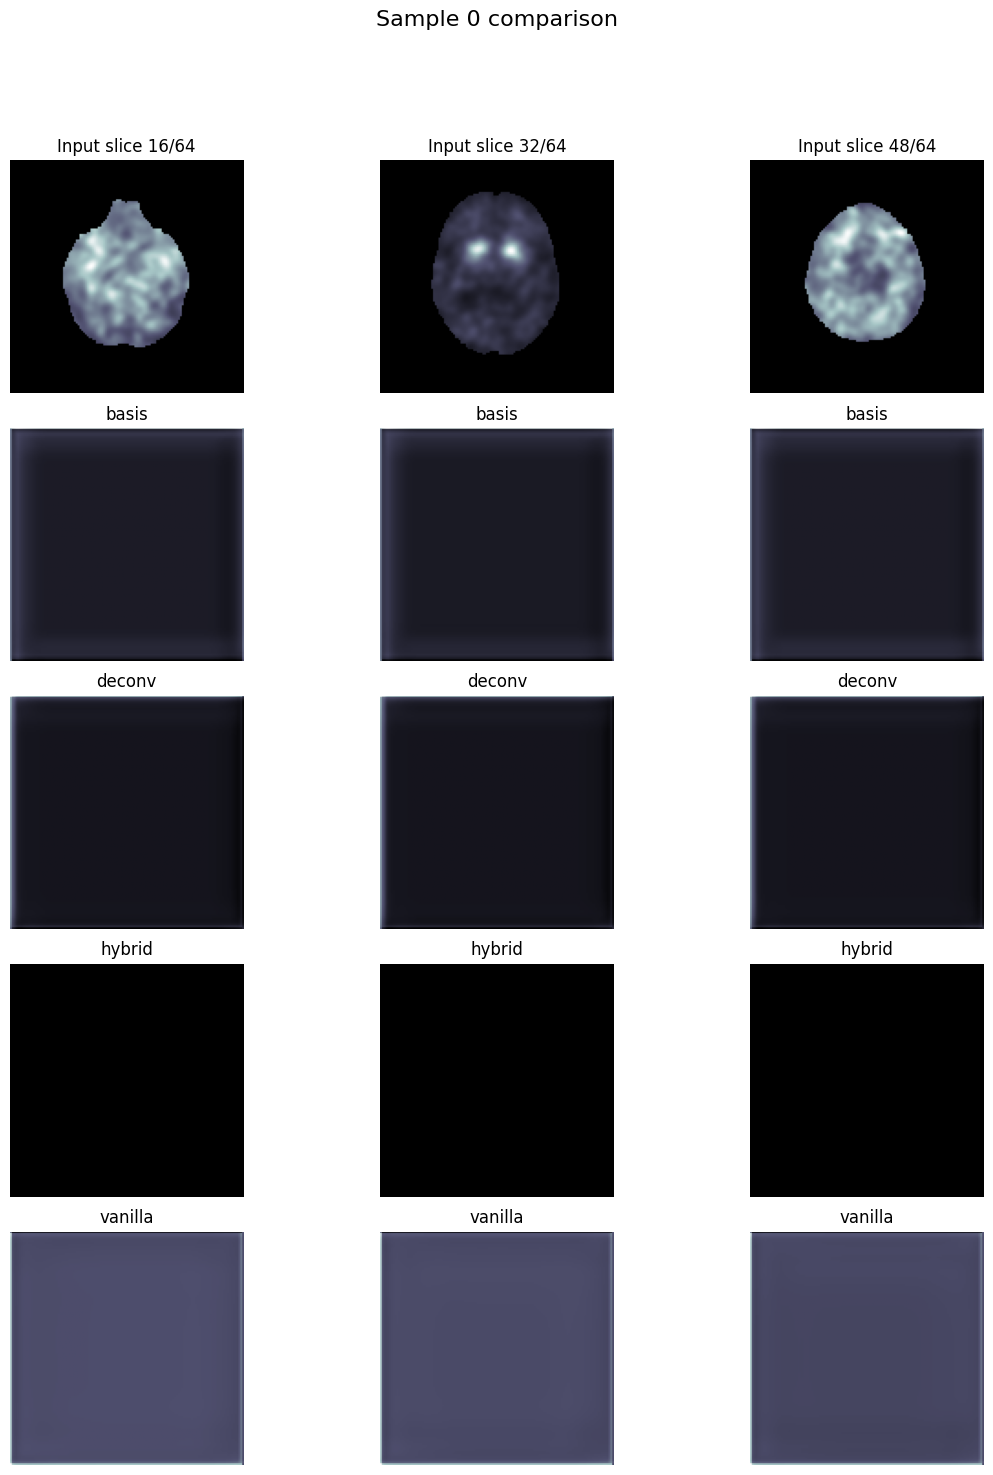

In [32]:

def plot_sample(sample_idx, slices=(32, 48), cmap="bone"):
    sample_recons = [r for r in recon_bank if r["sample"] == sample_idx]
    assert sample_recons, f"No reconstructions stored for sample {sample_idx}"

    variants = sorted({r["variant"] for r in sample_recons})
    inputs = sample_recons[0]["input"]  # same input for each variant
    D = inputs.shape[-3]

    fig, axes = plt.subplots(len(variants)+1, len(slices), figsize=(4*len(slices), 3*(len(variants)+1)))
    fig.suptitle(f"Sample {sample_idx} comparison", fontsize=16)

    for col, slice_idx in enumerate(slices):
        axes[0, col].imshow(inputs[0,0,slice_idx].numpy(), cmap=cmap)
        axes[0, col].set_title(f"Input slice {slice_idx}/{D}")
        axes[0, col].axis("off")

        for row, variant in enumerate(variants, start=1):
            recon = next(r["recon"] for r in sample_recons if r["variant"] == variant)
            axes[row, col].imshow(recon[0,0,slice_idx].numpy(), cmap=cmap)
            axes[row, col].set_title(f"{variant}")
            axes[row, col].axis("off")

    plt.tight_layout()
    plt.subplots_adjust(top=0.88)
    plt.show()

plot_sample(sample_idx=0, slices=(16,32,48))

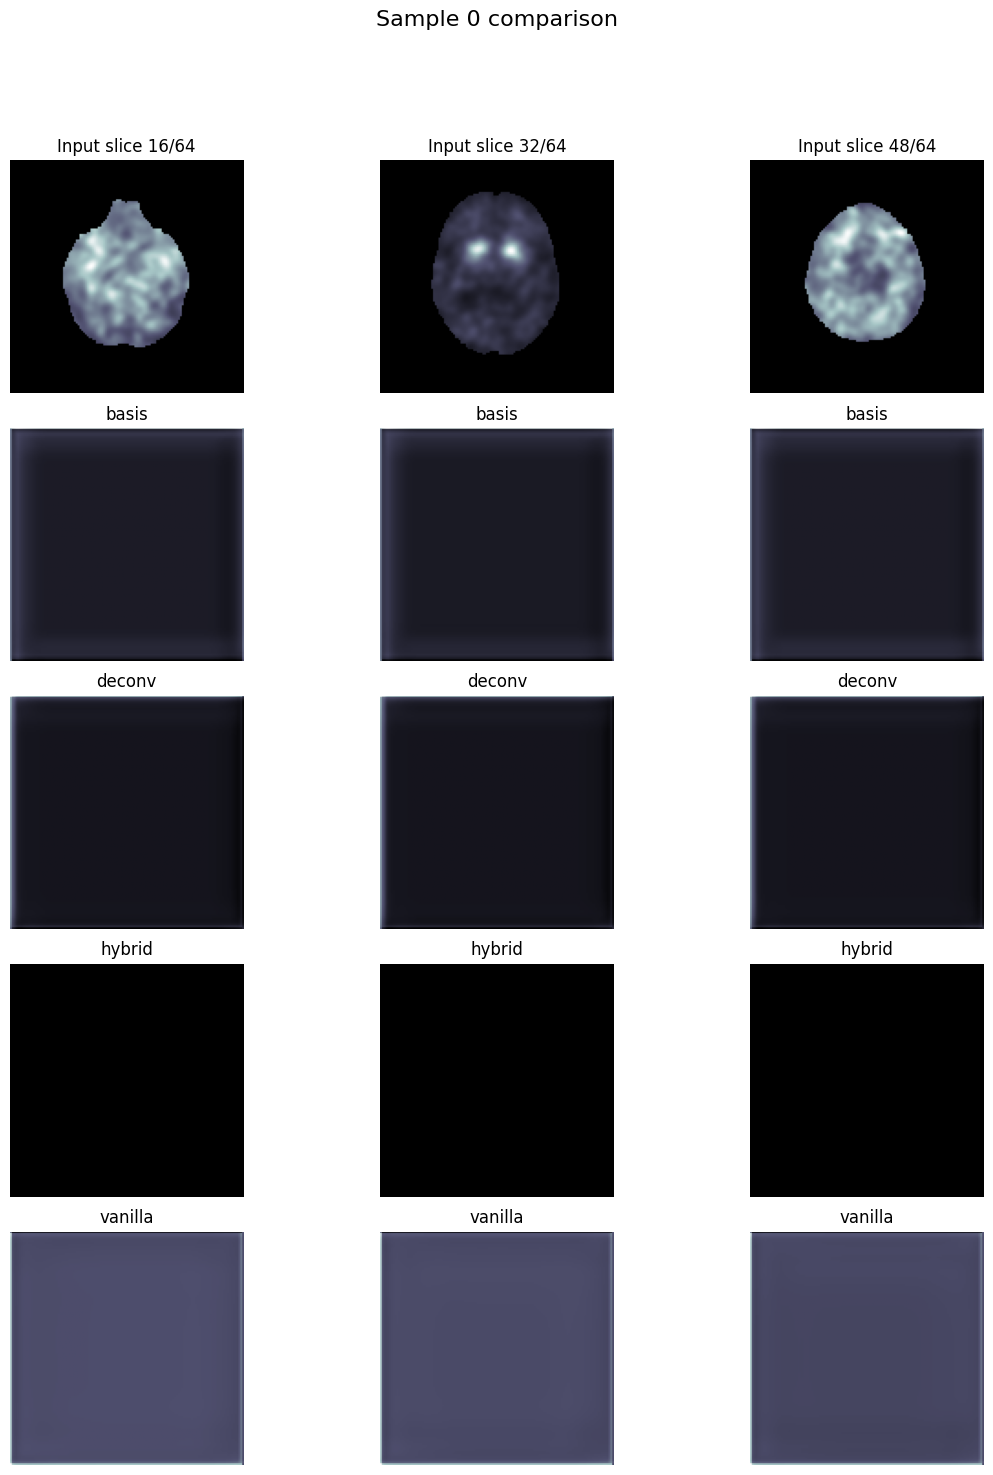

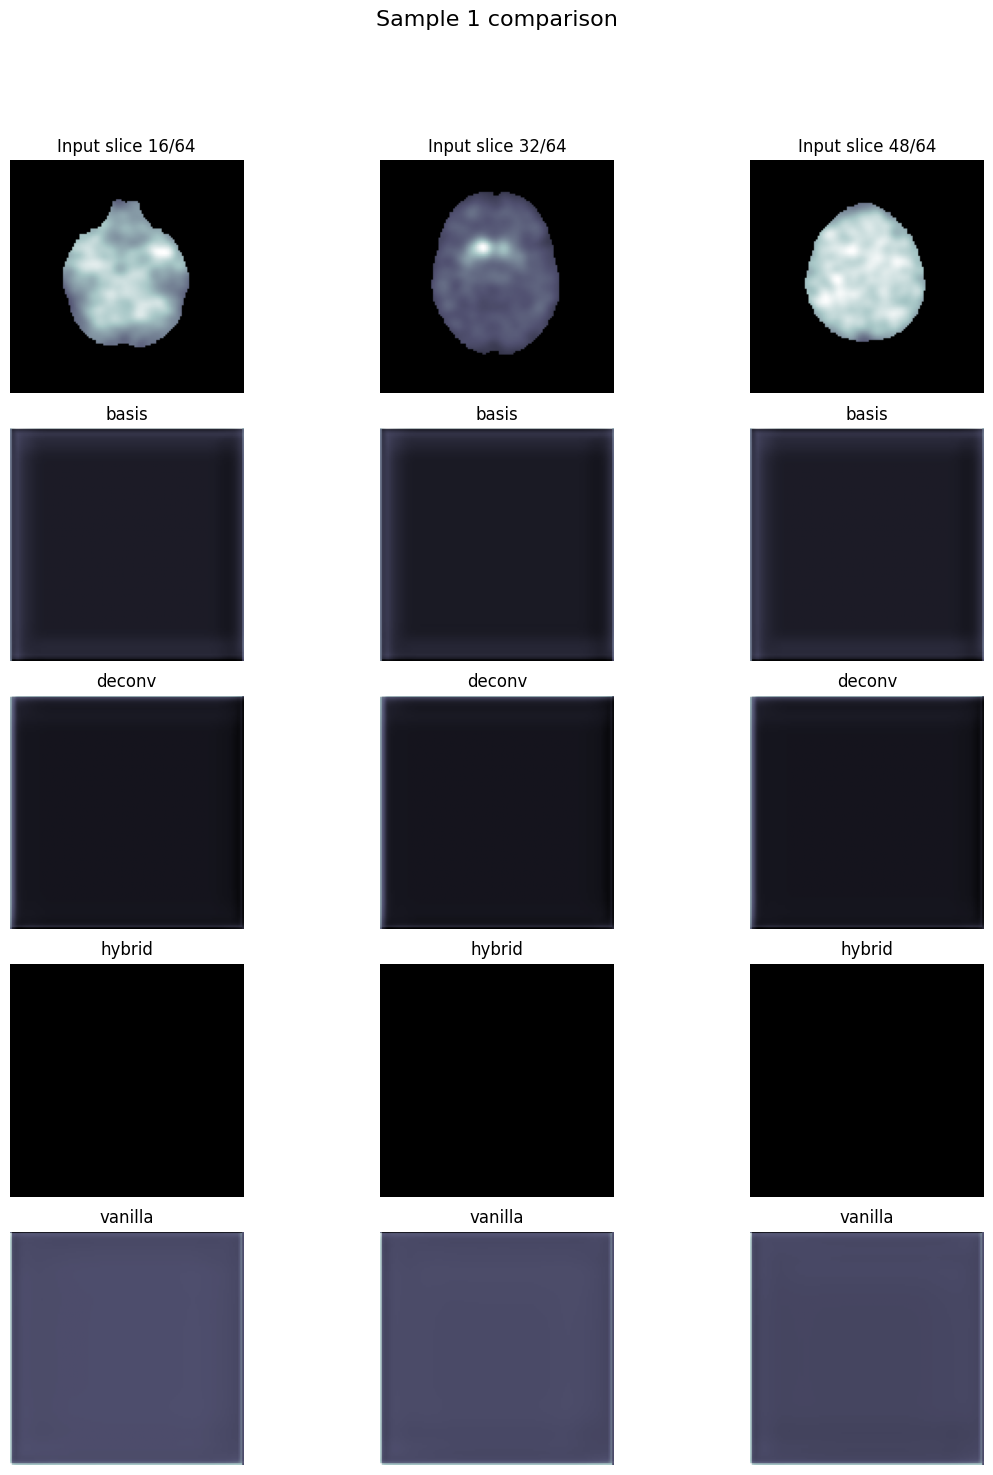

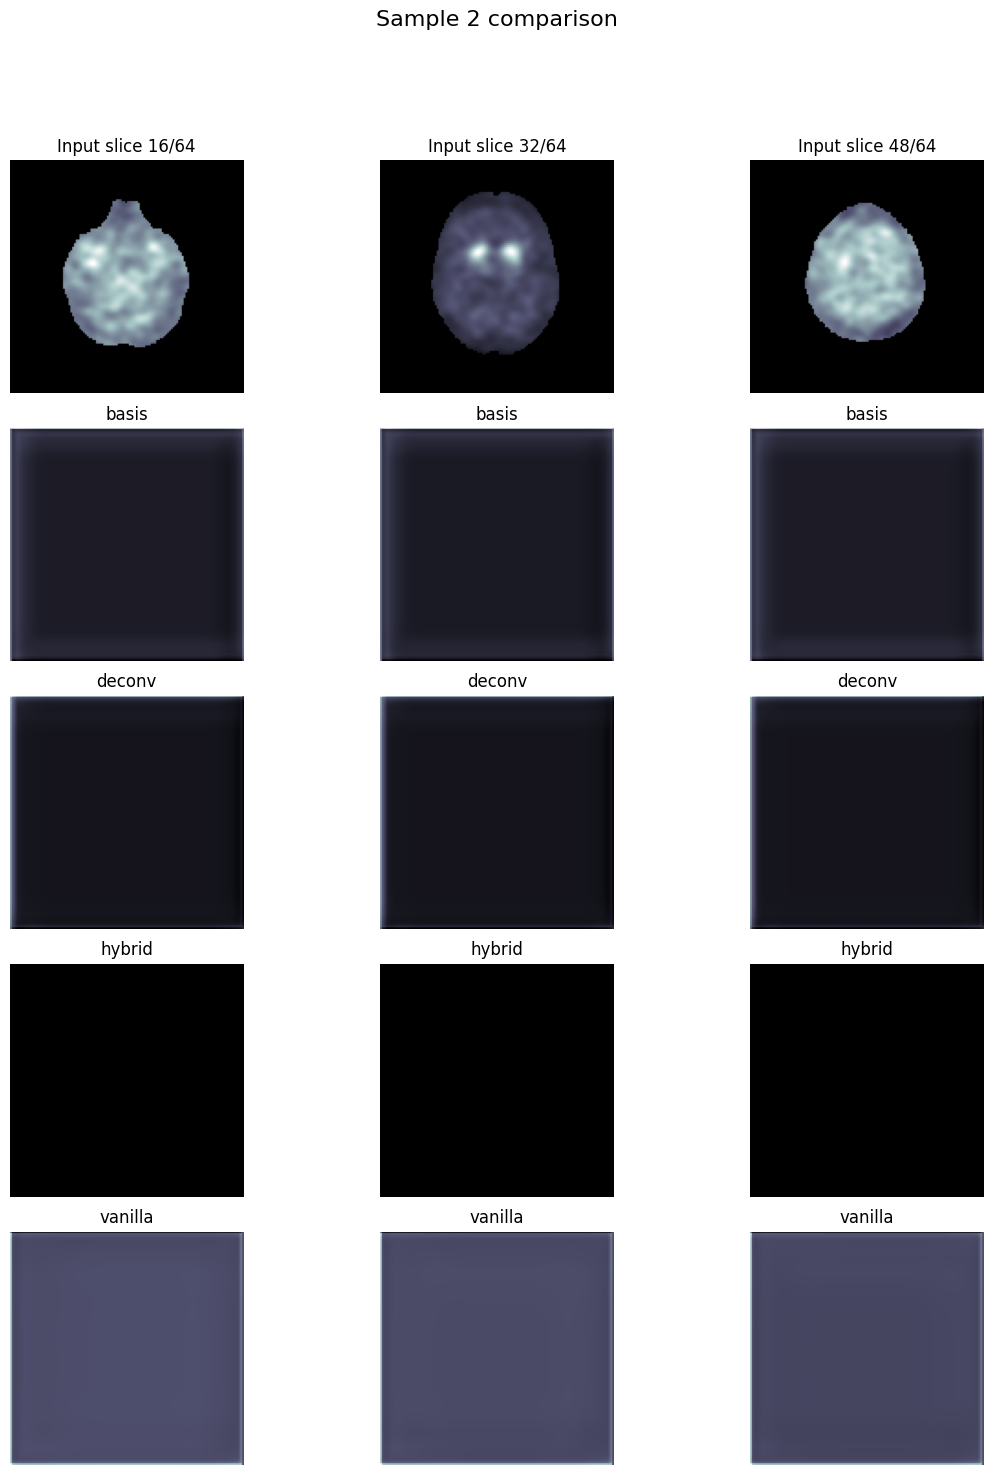

In [33]:
for idx in range(min(3, len(eval_dataset))):
    plot_sample(idx, slices=(16, 32, 48))